## Imports

In [1]:
import sys
import os
import torch
import torch.utils.data as data
import torch.nn as nn

sys.path.append(os.path.abspath('../../'))

import neuro_fuzzy_toolbox as nft

## Data

In [2]:
x_train = 2 * torch.rand(200, 3) - 1
x_train

tensor([[-5.6383e-01,  1.2261e-01, -5.1724e-01],
        [-2.9033e-01,  7.1825e-01,  4.3754e-01],
        [-3.3544e-01,  2.6824e-01,  1.5603e-01],
        [-2.0410e-02,  6.4050e-01, -6.5829e-01],
        [ 2.6922e-01,  7.3181e-01, -4.1618e-01],
        [-1.3360e-01, -4.7966e-01,  9.0654e-01],
        [-6.2980e-01, -5.0139e-01,  1.6515e-01],
        [-1.7839e-02,  9.9033e-01, -7.2006e-02],
        [ 6.7558e-01, -4.5450e-01, -5.9010e-01],
        [ 5.4393e-01,  6.5209e-01, -4.8144e-01],
        [ 5.2684e-01,  5.3907e-01,  1.7654e-02],
        [-4.9301e-01, -7.4487e-02,  3.2063e-01],
        [-2.6584e-01,  4.7741e-01, -8.4026e-01],
        [ 4.3978e-01, -5.7153e-01,  6.3712e-01],
        [-1.8806e-01,  5.3091e-01,  8.2467e-01],
        [-8.0441e-01, -5.1740e-01,  6.2154e-01],
        [-3.1799e-01,  6.3914e-01, -3.0790e-01],
        [-1.1320e-01, -3.8070e-01,  7.5527e-01],
        [ 1.0516e-01,  9.5691e-01, -6.8241e-02],
        [-4.1333e-01,  2.8712e-01,  6.4491e-02],
        [ 7.3742e-01

In [3]:
y_train = torch.rand(200)
y_train

tensor([0.2887, 0.7978, 0.0730, 0.8427, 0.3065, 0.2805, 0.8962, 0.2722, 0.1966,
        0.2392, 0.4812, 0.1227, 0.5095, 0.1274, 0.3929, 0.5301, 0.0566, 0.1517,
        0.8082, 0.4649, 0.4674, 0.3788, 0.1844, 0.0415, 0.5096, 0.8131, 0.0655,
        0.9744, 0.9351, 0.4085, 0.9054, 0.6242, 0.6010, 0.7221, 0.2998, 0.2103,
        0.5371, 0.5105, 0.8413, 0.8564, 0.7090, 0.9709, 0.1517, 0.7113, 0.4976,
        0.9791, 0.5996, 0.4355, 0.2801, 0.2205, 0.6745, 0.2442, 0.6984, 0.6478,
        0.8036, 0.1939, 0.6404, 0.6985, 0.8729, 0.2536, 0.0447, 0.6298, 0.6714,
        0.1551, 0.8400, 0.6610, 0.9711, 0.0802, 0.3354, 0.4640, 0.4826, 0.1146,
        0.2901, 0.3961, 0.6850, 0.8863, 0.9227, 0.0310, 0.4786, 0.2533, 0.9624,
        0.2873, 0.0370, 0.7844, 0.9900, 0.3642, 0.3563, 0.6079, 0.1230, 0.6698,
        0.5922, 0.3208, 0.8173, 0.2054, 0.7015, 0.7877, 0.6669, 0.0522, 0.9789,
        0.9666, 0.6052, 0.6310, 0.7185, 0.5962, 0.8199, 0.0806, 0.1530, 0.8316,
        0.3593, 0.7240, 0.3600, 0.0106, 

## Model

In [4]:
model = nft.h_ANFIS(
    input_size=x_train.shape[1], # 3 features
    num_mfs=3, # 4 funciones de membresía
    outputs=1, # 1 salida
    membership_function=nft.Gaussian_MF, # Función de membresía gaussiana
    output_type='default', # Tipo de salida: default
)

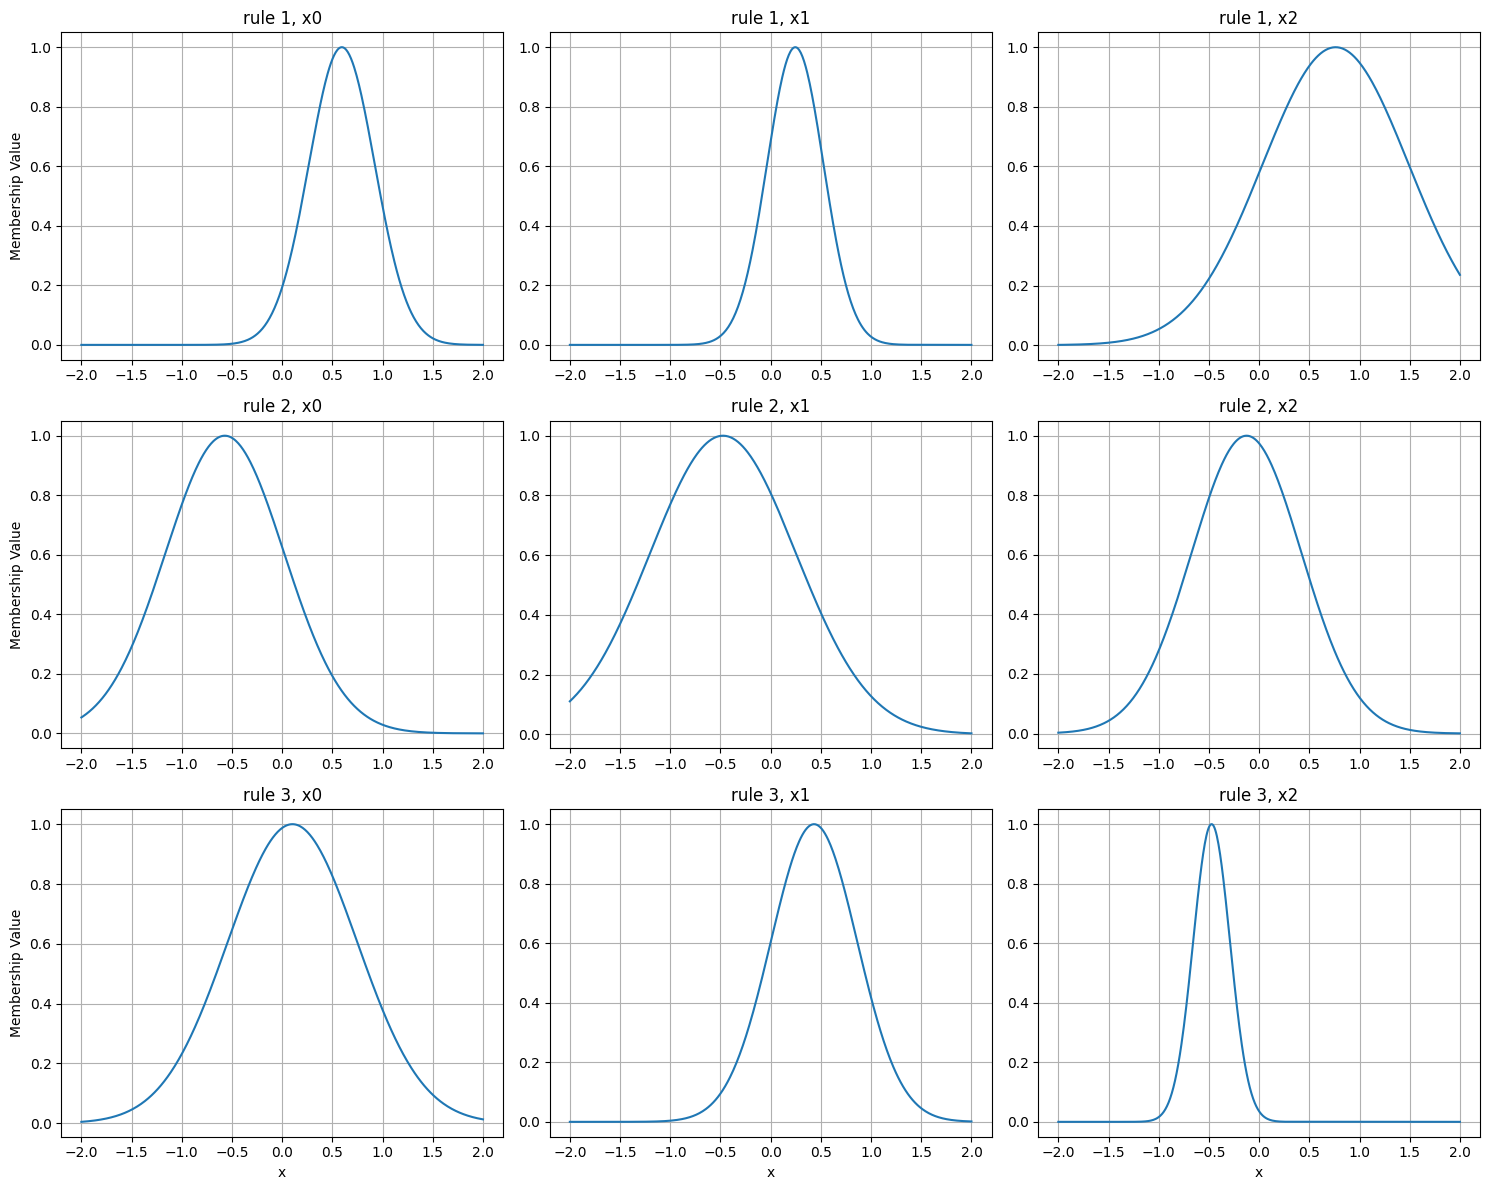

In [5]:
model.plot_premises()

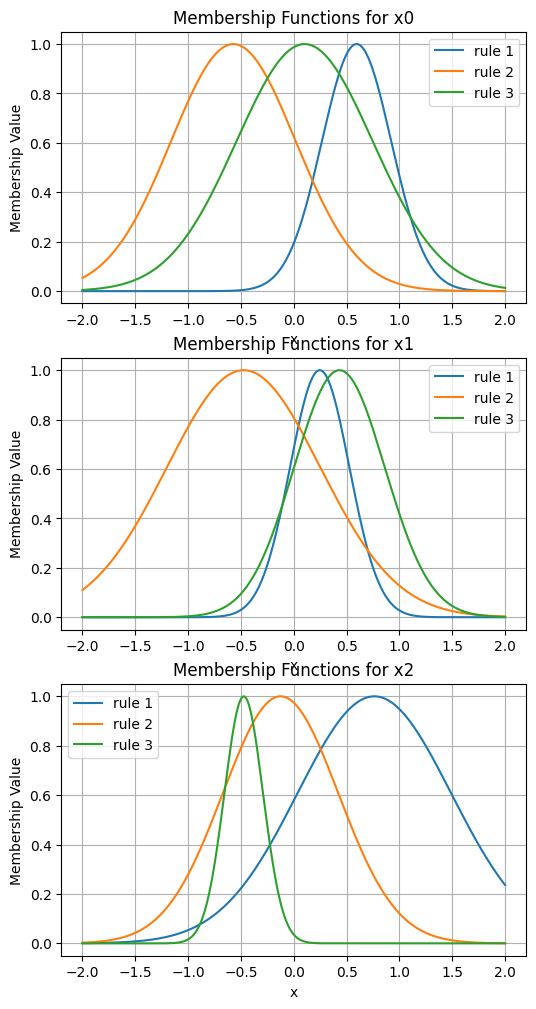

In [6]:
model.plot_premises(group_by_dim=True)

In [7]:
model.init_premises(x_train)

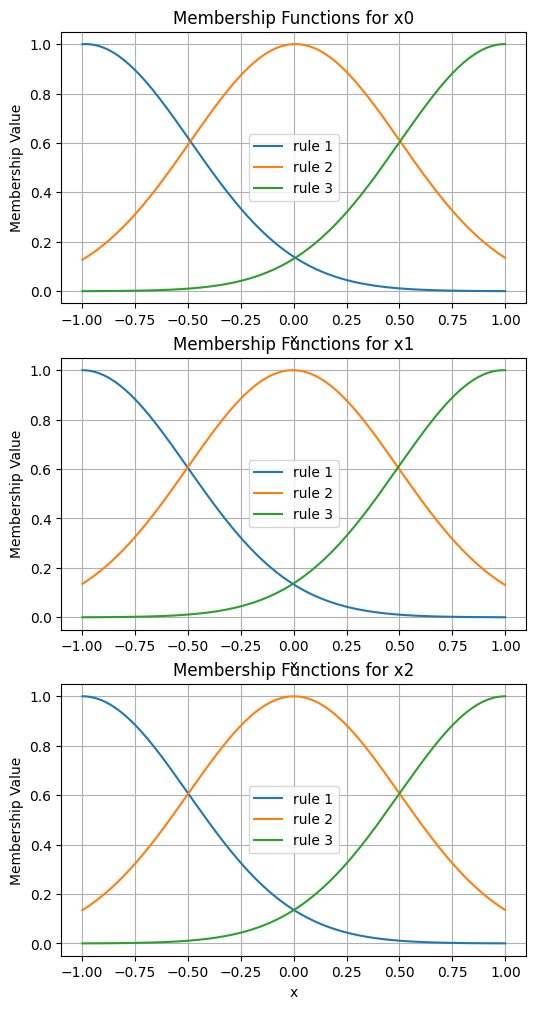

In [8]:
model.plot_premises(group_by_dim=True)

In [9]:
model.get_premises_structure()

x0                  x1                  x2          
              mu     sigma        mu     sigma        mu     sigma
rule 1 -0.982798  0.495328 -0.997963  0.497073 -0.996606  0.498919
rule 2  0.007858  0.495328 -0.003816  0.497073  0.001232  0.498919
rule 3  0.998515  0.495328  0.990331  0.497073  0.999070  0.498919

In [10]:
model.get_premises()

tensor([[[-0.9828,  0.4953],
         [ 0.0079,  0.4953],
         [ 0.9985,  0.4953]],

        [[-0.9980,  0.4971],
         [-0.0038,  0.4971],
         [ 0.9903,  0.4971]],

        [[-0.9966,  0.4989],
         [ 0.0012,  0.4989],
         [ 0.9991,  0.4989]]])

In [11]:
model.get_consequents_structure()[0]

,x0,x1,x2,
,c0,c1,c2,c3
rule 1,-0.797273,0.710968,0.446933,0.671923
rule 2,0.456102,-0.260706,0.814157,0.483260
rule 3,0.233972,0.111409,0.876659,0.082953
rule 4,-0.190166,-0.781747,-0.469856,-0.082256
rule 5,0.332154,0.012849,0.319565,-0.263351
rule 6,0.251709,-0.199881,0.772836,0.127733
rule 7,0.405021,0.024747,0.159838,0.080164
rule 8,-0.619380,-0.934333,0.588287,-0.316306
rule 9,0.712079,-0.380091,-0.869338,-0.899618


In [12]:
model.init_consequents(x_train, y_train, driver="gelss", ridge_lambda=0.1)

In [13]:
model.get_consequents_structure()[0]

,x0,x1,x2,
,c0,c1,c2,c3
rule 1,-0.358135,-0.146784,-0.285531,-0.015275
rule 2,0.175886,-0.141146,0.388349,0.148328
rule 3,0.042935,-0.218371,0.368081,0.405911
rule 4,-0.159120,0.155316,-0.161974,0.187980
rule 5,-0.262787,0.560127,0.079072,0.406342
rule 6,0.042884,-0.333931,0.426711,0.419039
rule 7,-0.406941,0.132934,0.011651,0.228705
rule 8,-0.325374,-0.087849,0.162852,0.585086
rule 9,-0.146632,0.448016,-0.013979,0.205384


In [14]:
model.get_rules_structure()

premises                                                    \
               x0                  x1                  x2             
               mu     sigma        mu     sigma        mu     sigma   
rule 1  -0.982798  0.495328 -0.997963  0.497073 -0.996606  0.498919   
rule 2  -0.982798  0.495328 -0.997963  0.497073  0.001232  0.498919   
rule 3  -0.982798  0.495328 -0.997963  0.497073  0.999070  0.498919   
rule 4  -0.982798  0.495328 -0.003816  0.497073 -0.996606  0.498919   
rule 5  -0.982798  0.495328 -0.003816  0.497073  0.001232  0.498919   
rule 6  -0.982798  0.495328 -0.003816  0.497073  0.999070  0.498919   
rule 7  -0.982798  0.495328  0.990331  0.497073 -0.996606  0.498919   
rule 8  -0.982798  0.495328  0.990331  0.497073  0.001232  0.498919   
rule 9  -0.982798  0.495328  0.990331  0.497073  0.999070  0.498919   
rule 10  0.007858  0.495328 -0.997963  0.497073 -0.996606  0.498919   
rule 11  0.007858  0.495328 -0.997963  0.497073  0.001232  0.498919   
rule 12  0.007858  0.495328 -0.997963  0.497073  0.999070  0.498919   
rule 13  0.007858  0.495328 -0.003816  0.497073 -0.996606  0.498919   
rule 14  0.007858  0.495328 -0.003816  0.497073  0.001232  0.498919   
rule 15  0.007858  0.495328 -0.003816  0.497073  0.999070  0.498919   
rule 16  0.007858  0.495328  0.990331  0.497073 -0.996606  0.498919   
rule 17  0.007858  0.495328  0.990331  0.497073  0.001232  0.498919   
rule 18  0.007858  0.495328  0.990331  0.497073  0.999070  0.498919   
rule 19  0.998515  0.495328 -0.997963  0.497073 -0.996606  0.498919   
rule 20  0.998515  0.495328 -0.997963  0.497073  0.001232  0.498919   
rule 21  0.998515  0.495328 -0.997963  0.497073  0.999070  0.498919   
rule 22  0.998515  0.495328 -0.003816  0.497073 -0.996606  0.498919   
rule 23  0.998515  0.495328 -0.003816  0.497073  0.001232  0.498919   
rule 24  0.998515  0.495328 -0.003816  0.497073  0.999070  0.498919   
rule 25  0.998515  0.495328  0.990331  0.497073 -0.996606  0.498919   
rule 26  0.998515  0.495328  0.990331  0.497073  0.001232  0.498919   
rule 27  0.998515  0.495328  0.990331  0.497073  0.999070  0.498919   

        output 1 consequents                                
                          x0        x1        x2            
                          c0        c1        c2        c3  
rule 1             -0.358135 -0.146784 -0.285531 -0.015275  
rule 2              0.175886 -0.141146  0.388349  0.148328  
rule 3              0.042935 -0.218371  0.368081  0.405911  
rule 4             -0.159120  0.155316 -0.161974  0.187980  
rule 5             -0.262787  0.560127  0.079072  0.406342  
rule 6              0.042884 -0.333931  0.426711  0.419039  
rule 7             -0.406941  0.132934  0.011651  0.228705  
rule 8             -0.325374 -0.087849  0.162852  0.585086  
rule 9             -0.146632  0.448016 -0.013979  0.205384  
rule 10             0.457585 -0.419622 -0.191289 -0.249879  
rule 11            -0.027981 -0.528131  0.339568  0.726504  
rule 12            -0.338737  0.116222 -0.062451 -0.060461  
rule 13             0.192704  0.405458 -0.614454  0.551125  
rule 14             0.363377  0.173857  0.079559  0.363314  
rule 15            -0.143845  0.026019  0.338759  0.330438  
rule 16             0.293382  0.209102  0.168864  0.263913  
rule 17             0.093104  0.119324  0.466558  0.674238  
rule 18            -0.176253  0.165396 -0.273901  0.123985  
rule 19             0.238409 -0.288723 -0.352630  0.190777  
rule 20            -0.104213  0.191803  0.279235  0.014783  
rule 21             0.230874 -0.165002  0.143957  0.287434  
rule 22             0.125026 -0.324050 -0.122083  0.330470  
rule 23             0.258215 -0.271122  0.078802  0.613842  
rule 24            -0.033730 -0.124659  0.033714  0.248183  
rule 25             0.076299  0.289877  0.092430 -0.025469  
rule 26            -0.151324 -0.027149  0.124044 -0.022925  
rule 27             0.523059  0.305664  0.299696  0.369461

In [15]:
model(x_train[:10])

tensor([0.4403, 0.5787, 0.4717, 0.4884, 0.4519, 0.4401, 0.3671, 0.5925, 0.5480,
        0.3712], grad_fn=<SqueezeBackward1>)

In [16]:
with torch.no_grad():
    output = model(x_train[:10])

print(output)

tensor([0.4403, 0.5787, 0.4717, 0.4884, 0.4519, 0.4401, 0.3671, 0.5925, 0.5480,
        0.3712])


In [17]:
model.predict(x_train[:10])

tensor([0.4403, 0.5787, 0.4717, 0.4884, 0.4519, 0.4401, 0.3671, 0.5925, 0.5480,
        0.3712])

## Binary output

In [18]:
x_train = 2 * torch.rand(200, 3) - 1

In [19]:
y_train = torch.randint(0, 2, (200,))
y_train[:10]

tensor([1, 1, 0, 1, 0, 0, 1, 1, 0, 0])

In [20]:
bin_model = nft.h_ANFIS(
    input_size=x_train.shape[1], # 3 features
    num_mfs=3, # 3 funciones de membresía
    outputs=1, # 1 salida
    membership_function=nft.Gaussian_MF, # Función de membresía gaussiana
    output_type='sigmoid', # Tipo de salida: capa sigmoide
)

In [21]:
bin_model.predict(x_train[:10])

tensor([0, 1, 0, 0, 1, 1, 0, 1, 1, 0])

In [22]:
bin_model(x_train[:10])

tensor([0.4852, 0.6445, 0.3559, 0.4583, 0.5242, 0.5629, 0.4201, 0.5076, 0.5424,
        0.4792], grad_fn=<SigmoidBackward0>)

## Multiclass output

In [23]:
x_train = 2 * torch.rand(200, 3) - 1

In [24]:
y_train = torch.randint(0, 4, (200,))
y_train[:10]

tensor([1, 3, 0, 1, 1, 3, 3, 1, 1, 2])

In [25]:
mul_class_model = nft.h_ANFIS(
    input_size=x_train.shape[1], # 3 features
    num_mfs=3, # 3 funciones de membresía
    outputs=4, # 4 clases
    membership_function=nft.Gaussian_MF, # Función de membresía gaussiana
    output_type='softmax', # Tipo de salida: capa softmax
)

In [26]:
mul_class_model.predict(x_train[:10])

tensor([3, 1, 1, 2, 0, 3, 0, 0, 2, 0])

In [27]:
mul_class_model(x_train[:10])

tensor([[-0.0261, -0.3504, -0.0743,  0.0713],
        [ 0.2721,  0.3889, -0.5435, -0.0655],
        [-0.7979,  0.4275,  0.2665, -0.0451],
        [-0.3099,  0.2032,  0.2272, -0.2094],
        [ 0.2348, -0.2545, -0.2036,  0.1285],
        [ 0.0462,  0.2699,  0.1366,  0.5920],
        [ 0.4462,  0.3268, -0.0011, -0.1307],
        [ 0.5962,  0.3458,  0.1098,  0.0297],
        [-0.4207,  0.1081,  0.3559, -0.2360],
        [ 0.6974,  0.3627, -0.0370, -0.2308]], grad_fn=<SqueezeBackward1>)

In [28]:
mul_class_model(x_train[:10], return_probs=True)

tensor([[0.2647, 0.1914, 0.2522, 0.2918],
        [0.3049, 0.3427, 0.1349, 0.2175],
        [0.1061, 0.3612, 0.3075, 0.2252],
        [0.1822, 0.3044, 0.3118, 0.2015],
        [0.3167, 0.1942, 0.2043, 0.2848],
        [0.1972, 0.2466, 0.2158, 0.3403],
        [0.3238, 0.2873, 0.2070, 0.1819],
        [0.3377, 0.2629, 0.2077, 0.1917],
        [0.1646, 0.2794, 0.3579, 0.1980],
        [0.3860, 0.2762, 0.1852, 0.1526]], grad_fn=<SoftmaxBackward0>)

In [29]:
mul_class_model.get_rules_structure()

premises                                                    \
               x0                  x1                  x2             
               mu     sigma        mu     sigma        mu     sigma   
rule 1   0.003410  0.310690 -0.307824  0.908414  0.427718  0.462387   
rule 2   0.003410  0.310690 -0.307824  0.908414  0.122913  0.347750   
rule 3   0.003410  0.310690 -0.307824  0.908414  0.785106  0.831199   
rule 4   0.003410  0.310690 -0.556865  0.124827  0.427718  0.462387   
rule 5   0.003410  0.310690 -0.556865  0.124827  0.122913  0.347750   
rule 6   0.003410  0.310690 -0.556865  0.124827  0.785106  0.831199   
rule 7   0.003410  0.310690  0.229926  0.392338  0.427718  0.462387   
rule 8   0.003410  0.310690  0.229926  0.392338  0.122913  0.347750   
rule 9   0.003410  0.310690  0.229926  0.392338  0.785106  0.831199   
rule 10  0.907912  0.797650 -0.307824  0.908414  0.427718  0.462387   
rule 11  0.907912  0.797650 -0.307824  0.908414  0.122913  0.347750   
rule 12  0.907912  0.797650 -0.307824  0.908414  0.785106  0.831199   
rule 13  0.907912  0.797650 -0.556865  0.124827  0.427718  0.462387   
rule 14  0.907912  0.797650 -0.556865  0.124827  0.122913  0.347750   
rule 15  0.907912  0.797650 -0.556865  0.124827  0.785106  0.831199   
rule 16  0.907912  0.797650  0.229926  0.392338  0.427718  0.462387   
rule 17  0.907912  0.797650  0.229926  0.392338  0.122913  0.347750   
rule 18  0.907912  0.797650  0.229926  0.392338  0.785106  0.831199   
rule 19 -0.961902  0.544127 -0.307824  0.908414  0.427718  0.462387   
rule 20 -0.961902  0.544127 -0.307824  0.908414  0.122913  0.347750   
rule 21 -0.961902  0.544127 -0.307824  0.908414  0.785106  0.831199   
rule 22 -0.961902  0.544127 -0.556865  0.124827  0.427718  0.462387   
rule 23 -0.961902  0.544127 -0.556865  0.124827  0.122913  0.347750   
rule 24 -0.961902  0.544127 -0.556865  0.124827  0.785106  0.831199   
rule 25 -0.961902  0.544127  0.229926  0.392338  0.427718  0.462387   
rule 26 -0.961902  0.544127  0.229926  0.392338  0.122913  0.347750   
rule 27 -0.961902  0.544127  0.229926  0.392338  0.785106  0.831199   

        output 1 consequents                                ...  \
                          x0        x1        x2            ...   
                          c0        c1        c2        c3  ...   
rule 1              0.616434  0.044938 -0.176850  0.886122  ...   
rule 2             -0.311261 -0.839549 -0.467027  0.449155  ...   
rule 3              0.792248 -0.277223 -0.219775  0.572998  ...   
rule 4              0.212239 -0.356103 -0.396780  0.554703  ...   
rule 5             -0.398818 -0.091656 -0.166932  0.995050  ...   
rule 6              0.904058  0.119791 -0.414096  0.384551  ...   
rule 7              0.025904 -0.946129  0.286066  0.427220  ...   
rule 8             -0.569777  0.561861  0.618913  0.216248  ...   
rule 9             -0.548752  0.557453  0.629603  0.681406  ...   
rule 10            -0.777055 -0.565769  0.882816 -0.486579  ...   
rule 11            -0.720918 -0.978010 -0.889046  0.608942  ...   
rule 12            -0.912016 -0.078444  0.770603 -0.239420  ...   
rule 13             0.743475  0.016387 -0.621228 -0.579731  ...   
rule 14            -0.367878  0.840232 -0.976511  0.890167  ...   
rule 15             0.078635  0.002208 -0.075879  0.269199  ...   
rule 16             0.610749 -0.957525  0.941518 -0.622219  ...   
rule 17            -0.741227  0.026051  0.132718  0.493322  ...   
rule 18            -0.815644  0.024968  0.089994 -0.485277  ...   
rule 19             0.788802 -0.827742  0.959608  0.037361  ...   
rule 20            -0.215264 -0.112708 -0.194029 -0.099696  ...   
rule 21             0.029627  0.625774 -0.656984  0.898577  ...   
rule 22             0.780945 -0.790247 -0.777844  0.487665  ...   
rule 23            -0.869553  0.341702  0.472538  0.967317  ...   
rule 24            -0.285066 -0.999584 -0.638212 -0.953361  ...   
rule 25             0.553062  0.877447  0.420369  0.630836  ...   
ru

In [30]:
print(mul_class_model.get_rules_structure().to_string())

         premises                                                   output 1 consequents                               output 2 consequents                               output 3 consequents                               output 4 consequents                              
               x0                  x1                  x2                             x0        x1        x2                             x0        x1        x2                             x0        x1        x2                             x0        x1        x2          
               mu     sigma        mu     sigma        mu     sigma                   c0        c1        c2        c3                   c0        c1        c2        c3                   c0        c1        c2        c3                   c0        c1        c2        c3
rule 1   0.003410  0.310690 -0.307824  0.908414  0.427718  0.462387             0.616434  0.044938 -0.176850  0.886122             0.126790 -0.318867 -0.750230 -0.146019             0.

## Multiple outputs

In [31]:
x_train = 2 * torch.rand(200, 2) - 1

In [32]:
model = nft.h_ANFIS(
    input_size=x_train.shape[1], # 2 features
    num_mfs=3, # 3 funciones de membresía
    outputs=2, # 2 salidas
    membership_function=nft.Gaussian_MF, # Función de membresía gaussiana
    output_type='default', # Tipo de salida: default
)

In [33]:
model.get_consequents_structure()

[              x0        x1          
               c0        c1        c2
 rule 1 -0.379771  0.668063 -0.645839
 rule 2  0.745497 -0.865207  0.116669
 rule 3  0.991431 -0.177031 -0.694728
 rule 4 -0.089254 -0.845264 -0.073068
 rule 5 -0.551773 -0.945123  0.297340
 rule 6 -0.215234 -0.597704 -0.393196
 rule 7 -0.590232  0.672489  0.113741
 rule 8  0.289277  0.830053  0.007884
 rule 9  0.055988 -0.991379 -0.512593,
               x0        x1          
               c0        c1        c2
 rule 1  0.445229  0.079765 -0.738391
 rule 2 -0.327717  0.255636  0.023456
 rule 3 -0.717829  0.069296  0.793459
 rule 4  0.307857  0.525331 -0.145257
 rule 5  0.739496  0.529061 -0.532108
 rule 6  0.118266 -0.485960 -0.538851
 rule 7 -0.293262  0.101271  0.081945
 rule 8 -0.185319 -0.646155  0.367650
 rule 9 -0.727689 -0.515857  0.328938]

In [34]:
model(x_train[:10])

tensor([[-0.1549, -0.0479],
        [-0.1093, -0.0643],
        [-0.1436,  0.0663],
        [-0.0728, -0.0914],
        [-0.1635,  0.0767],
        [ 0.0969, -0.2969],
        [-0.1194, -0.0703],
        [-0.0651, -0.1279],
        [-0.0651, -0.1611],
        [ 0.0774, -0.2616]], grad_fn=<SqueezeBackward1>)

## Multiclass problem

In [35]:
x_train = 2 * torch.rand(200, 2) - 1 # ejemplo de datos de entrenamiento con 2 features

model = nft.h_ANFIS(
    input_size=x_train.shape[1], # 3 features
    num_mfs=2, # 2 funciones de membresía
    outputs=3, # 3 salidas
    membership_function=nft.Gaussian_MF, # Función de membresía gaussiana
    output_type='softmax', # Tipo de salida: capa softmax
)

In [36]:
model(x_train[:10])

tensor([[ 0.2505, -0.9266,  0.5213],
        [-0.2054, -1.2223,  0.4114],
        [-0.1019, -0.4685, -0.2243],
        [ 0.1591, -0.8659,  0.4531],
        [ 0.1407, -0.0706, -0.1595],
        [ 0.3380, -0.8591, -0.2598],
        [ 0.3399, -1.1581,  0.8524],
        [ 0.2227, -0.8961,  0.5100],
        [ 0.1115, -0.9284,  0.4667],
        [ 0.3691, -0.8979, -0.3025]], grad_fn=<SqueezeBackward1>)

In [37]:
model(x_train[:10], return_probs=True)

tensor([[0.3818, 0.1177, 0.5005],
        [0.3111, 0.1125, 0.5764],
        [0.3879, 0.2689, 0.3432],
        [0.3703, 0.1329, 0.4969],
        [0.3921, 0.3174, 0.2904],
        [0.5399, 0.1631, 0.2970],
        [0.3457, 0.0773, 0.5771],
        [0.3760, 0.1228, 0.5012],
        [0.3597, 0.1272, 0.5131],
        [0.5579, 0.1571, 0.2850]], grad_fn=<SoftmaxBackward0>)

In [38]:
model.predict(x_train[:10])

tensor([2, 2, 0, 2, 0, 0, 2, 2, 2, 0])

# Rule Reduced

In [39]:
x_train = 2 * torch.rand(200, 2) - 1 # ejemplo de datos de entrenamiento con 2 features

In [40]:
rr_model = nft.rule_reduced_ANFIS(
    input_size=x_train.shape[1], # 2 features
    num_mfs=3, # 3 funciones de membresía
    outputs=1, # 1 salida
)

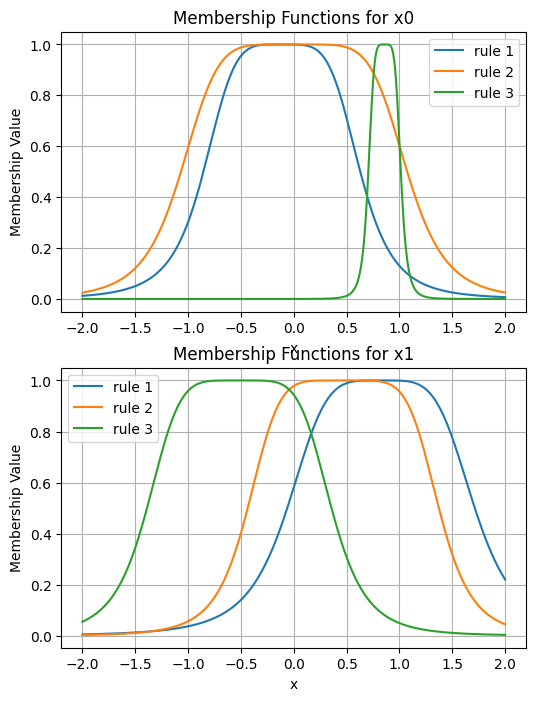

In [41]:
rr_model.plot_premises(group_by_dim=True)

In [42]:
rr_model.get_consequents_structure()[0]

,x0,x1,
,c0,c1,c2
rule 1,-0.707191,0.492422,0.915215
rule 2,0.238463,-0.445196,-0.103835
rule 3,0.502163,-0.386984,-0.545760


In [43]:
rr_model.get_rules_structure()

premises                                                    \
              x0                            x1                       
               a         b         c         a         b         c   
rule 1  0.742133  2.344519 -0.112824  0.887498  2.259055  0.825617   
rule 2  1.070537  2.921105  0.002814  0.904549  2.901842  0.468556   
rule 3  0.153626  2.572704  0.859268  0.873029  2.679551 -0.515786   

       output 1 consequents                      
                         x0        x1            
                         c0        c1        c2  
rule 1            -0.707191  0.492422  0.915215  
rule 2             0.238463 -0.445196 -0.103835  
rule 3             0.502163 -0.386984 -0.545760